In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = sns.load_dataset('titanic')

In [35]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [37]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [38]:
df.drop(['alive','embarked','who','deck','class','adult_male'],axis=1,inplace=True)


In [39]:
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,Southampton,True
3,1,1,female,35.0,1,0,53.1000,Southampton,False
4,0,3,male,35.0,0,0,8.0500,Southampton,True


<Axes: xlabel='age', ylabel='Count'>

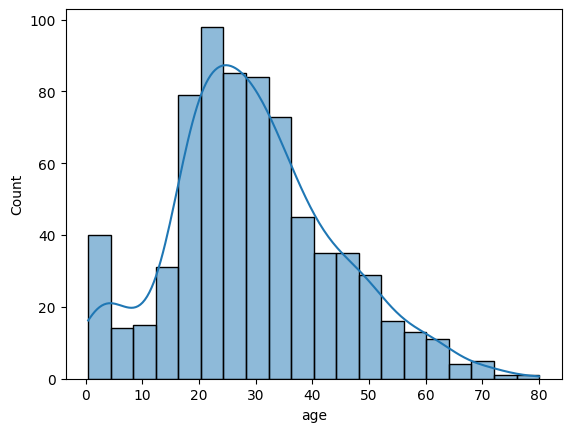

In [40]:
sns.histplot(df['age'],kde=True)

In [41]:
df['age'] =df['age'].fillna(df['age'].median())

In [42]:
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

In [43]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,Southampton,True
3,1,1,female,35.0,1,0,53.1000,Southampton,False
4,0,3,male,35.0,0,0,8.0500,Southampton,True


In [44]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embark_town,0
alone,0


In [45]:
#  EDA me always start with the target feature

<Axes: xlabel='survived', ylabel='count'>

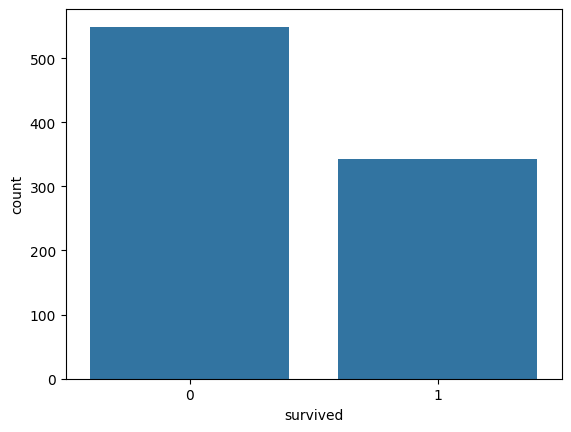

In [46]:
sns.countplot(x='survived',data=df)

In [47]:
df['survived'].value_counts(normalize=True)

,proportion
survived,
0,0.616162
1,0.383838


<Axes: xlabel='sex', ylabel='survived'>

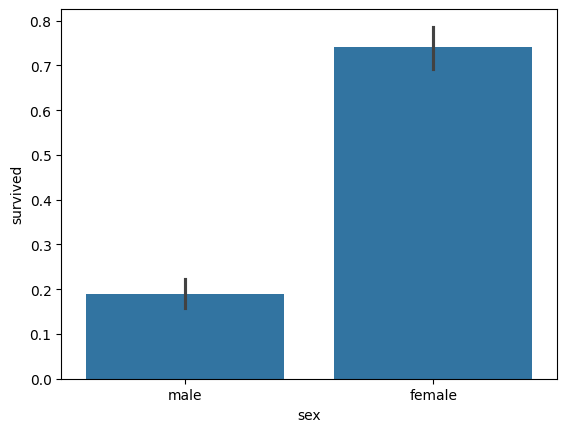

In [48]:
sns.barplot(x= 'sex',y='survived',data=df)

<Axes: xlabel='pclass', ylabel='survived'>

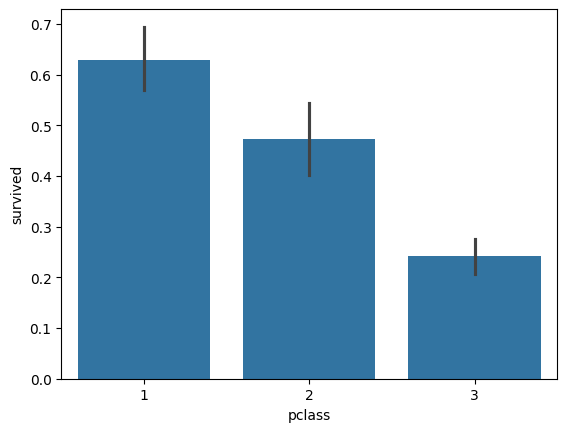

In [49]:
sns.barplot(x='pclass',y='survived',data=df)

In [50]:
# boxplot yaa  violenplot  yaa histplot use krenge jb ek categorical aur ek continuous
#  jb dono categorical ho to barplot

<Axes: xlabel='sex', ylabel='age'>

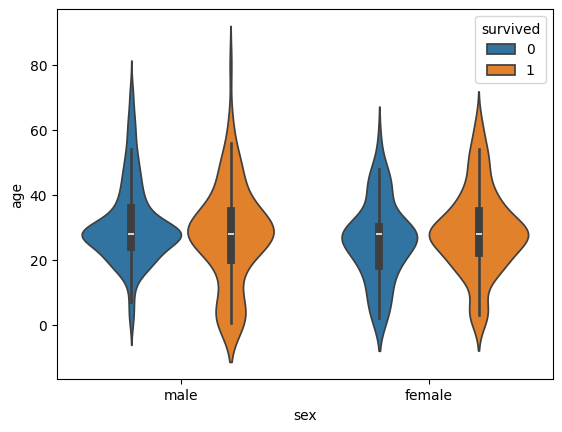

In [51]:
sns.violinplot(x='sex',y='age',hue='survived',data=df)

<Axes: xlabel='fare', ylabel='Count'>

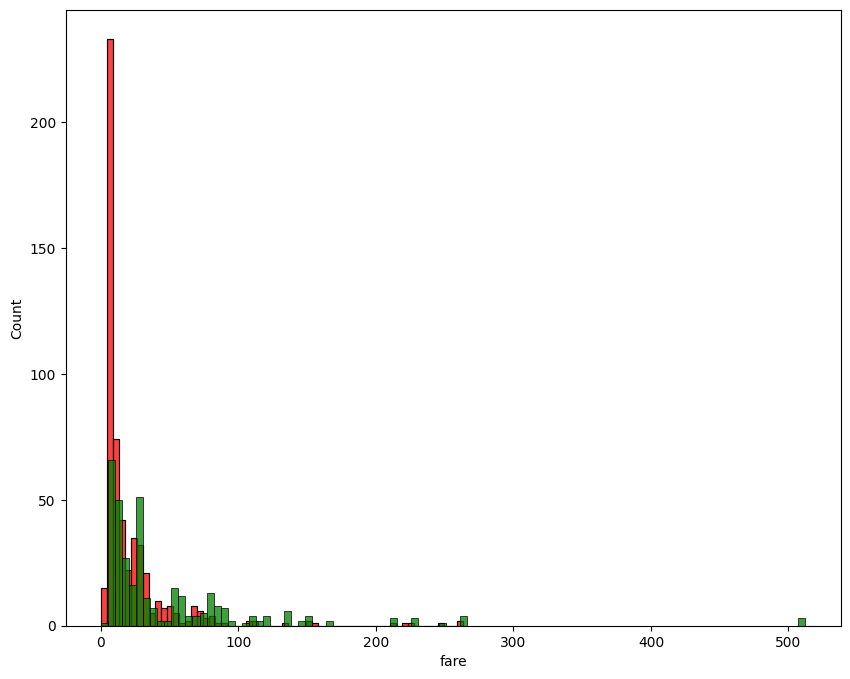

In [52]:
plt.figure(figsize=(10,8))
sns.histplot(df[df['survived']==0]['fare'],color='red')
sns.histplot(df[df['survived']==1]['fare'],color='green',bins=100)

<Axes: xlabel='sibsp', ylabel='survived'>

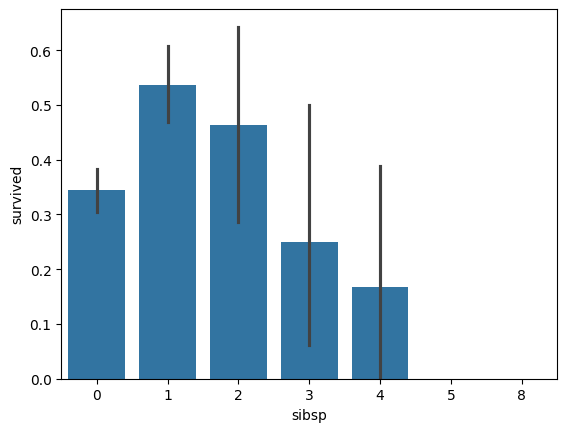

In [53]:
sns.barplot(x='sibsp',y='survived',data=df)

<Axes: xlabel='parch', ylabel='survived'>

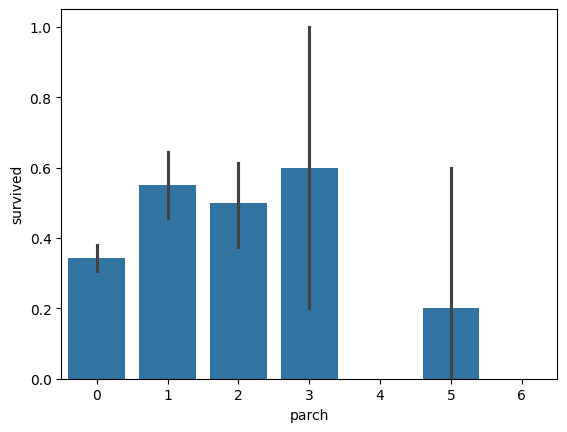

In [54]:
sns.barplot(x='parch',y='survived',data=df)

<Axes: xlabel='embark_town', ylabel='survived'>

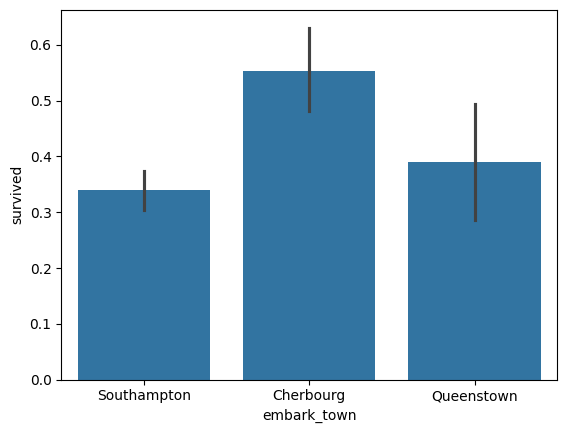

In [55]:
sns.barplot(x='embark_town',y='survived',data=df)

# First Encode then Split then  scaling then train test

In [56]:
df_encoded = pd.get_dummies(df,columns=['sex','embark_town'],drop_first=True)
df_encoded

,survived,pclass,age,sibsp,parch,fare,alone,sex_male,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,False,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,False,True
4,0,3,35.0,0,0,8.0500,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,True,True,False,True
887,1,1,19.0,0,0,30.0000,True,False,False,True
888,0,3,28.0,1,2,23.4500,False,False,False,True
889,1,1,26.0,0,0,30.0000,True,True,False,False


In [57]:
X= df_encoded.drop(['survived'],axis=1)
y= df_encoded['survived']

In [58]:
from sklearn.model_selection import train_test_split


In [59]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
model = LogisticRegression(max_iter=500)
model.fit(X_train,y_train)

LogisticRegression(max_iter=500)

In [62]:
y_pred = model.predict(X_test)

In [63]:
y_test

,survived
709,1
439,0
840,0
720,1
39,1
...,...
433,0
773,0
25,1
84,1


In [64]:
y_pred


array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

### Correlation Matrix

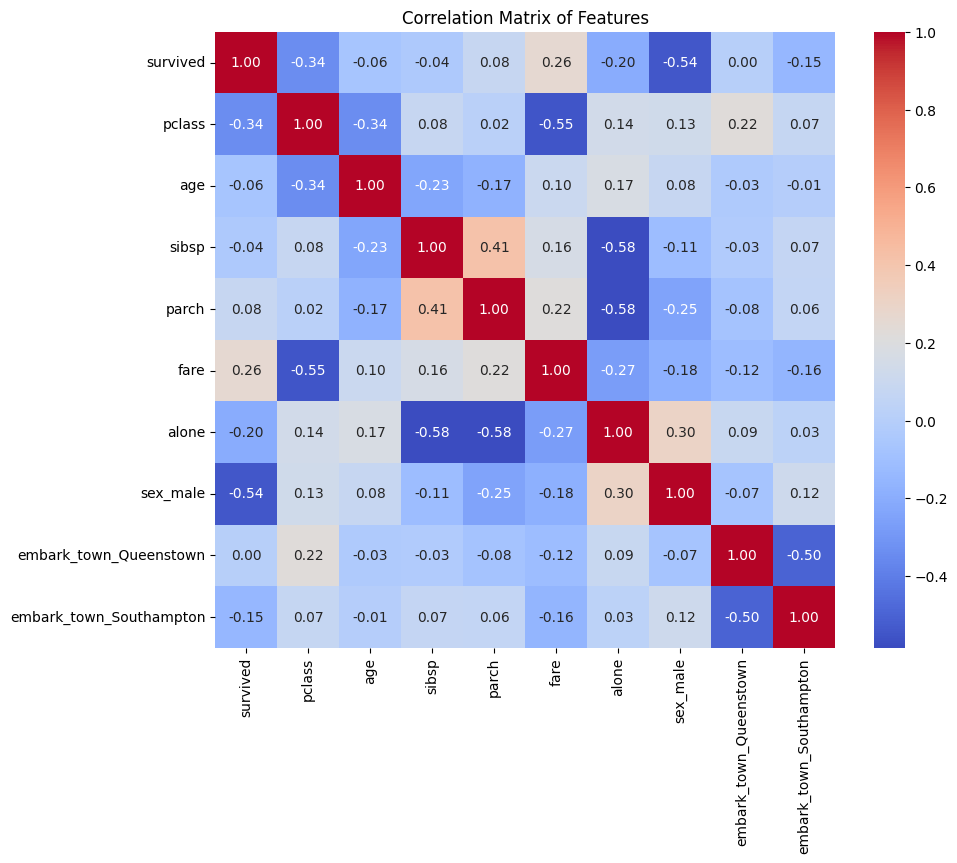

In [65]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

## Model Evaluation

In [66]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")


Accuracy Score: 0.80


Confusion Matrix:


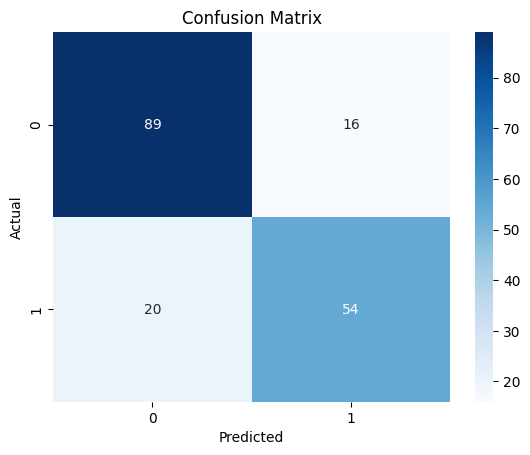

In [67]:
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [68]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

